In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from vizman import viz

base_dir = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm")
csv_files = {
    'humans': base_dir / "hcp_schaefer_100_dataset/05_mst_animal_0_compared_with_hcp_schaefer_100/summary_indiv_delta_con_for_exp_05_mst_animal_0_compared_with_hcp_schaefer_100.csv",
    'diffusion': base_dir / "kaysons_generated_networks_diffusion/05_mst_animal_0_compared_with_diffusion/summary_indiv_delta_con_for_exp_05_mst_animal_0_compared_with_diffusion.csv",
    'propagation': base_dir / "kaysons_generated_networks_propagation/05_mst_animal_0_compared_with_propagation/summary_indiv_delta_con_for_exp_05_mst_animal_0_compared_with_propagation.csv",
    'routing': base_dir / "kaysons_generated_networks_routing/05_mst_animal_0_compared_with_routing/summary_indiv_delta_con_for_exp_05_mst_animal_0_compared_with_routing.csv",
    'mami': base_dir / "suarez_MaMI_dataset/05_mst_animal_0_compared_with_mami/summary_indiv_delta_con_for_exp_05_mst_animal_0_compared_with_mami.csv"
}


Processing humans...
  Found 103 minima
Processing diffusion...
  Found 100 minima
Processing propagation...
  Found 100 minima
Processing routing...
  Found 100 minima
Processing mami...
  Found 225 minima


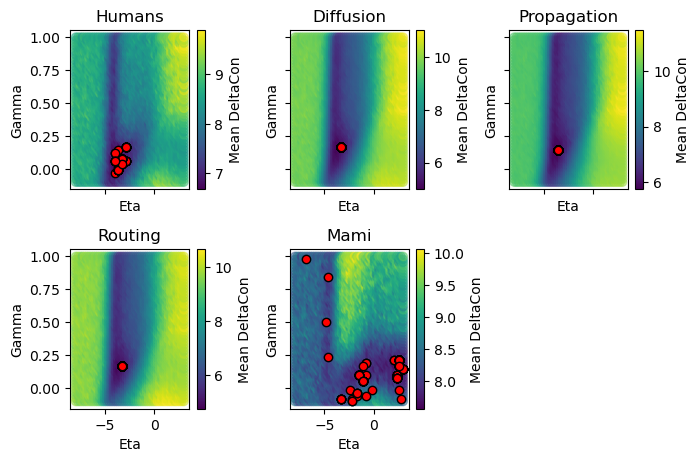

In [2]:

# Store all minima for each network type
all_minima = {}

# Do this in subplots
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=viz.cm_to_inch((18,12)), sharex=True, sharey=True, dpi=100)
axs = axs.flatten()

# Process each CSV file
for i, (network_name, csv_path) in enumerate(csv_files.items()):
    print(f"Processing {network_name}...")
    
    # Load the data
    df = pd.read_csv(csv_path)
    
    # Drop filename column if it exists
    if 'filename' in df.columns:
        df.drop(columns=["filename"], inplace=True)
    
    # Group by eta and gamma and calculate mean
    df_mean = df.groupby(["eta", "gamma"]).mean().reset_index()
    
    # Find minima for each subject (DeltaCon columns)
    delta_con_columns = [col for col in df_mean.columns if "DeltaCon_subject_" in col]
    
    df_mean["DeltaCon_mean"] = df_mean[delta_con_columns].mean(axis=1)
    
    minima_eta = []
    minima_gamma = []
    
    for col in delta_con_columns:
        # Find the row with minimum DeltaCon for this subject
        min_idx = df_mean[col].idxmin()
        minima_eta.append(df_mean.loc[min_idx, "eta"])
        minima_gamma.append(df_mean.loc[min_idx, "gamma"])
    
    all_minima[network_name] = {
        'eta': minima_eta,
        'gamma': minima_gamma,
        'df_mean': df_mean
    }
    print(f"  Found {len(minima_eta)} minima")
    axs[i].scatter(df_mean["eta"], df_mean["gamma"], c=df_mean["DeltaCon_mean"], label=network_name, alpha=0.5)
    axs[i].set_title(network_name.capitalize())
    axs[i].set_xlabel("Eta")
    axs[i].set_ylabel("Gamma")
    
    # Add minima points
    axs[i].scatter(minima_eta, minima_gamma, color='red', label='Minima', edgecolor='black')
    # axs[i].legend()
    # Add colorbar
    norm = plt.Normalize(df_mean["DeltaCon_mean"].min(), df_mean["DeltaCon_mean"].max())
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axs[i], label="Mean DeltaCon")
    
# Remove empty subplot
if len(csv_files) < len(axs):
    for j in range(len(csv_files), len(axs)):
        fig.delaxes(axs[j])

plt.tight_layout()

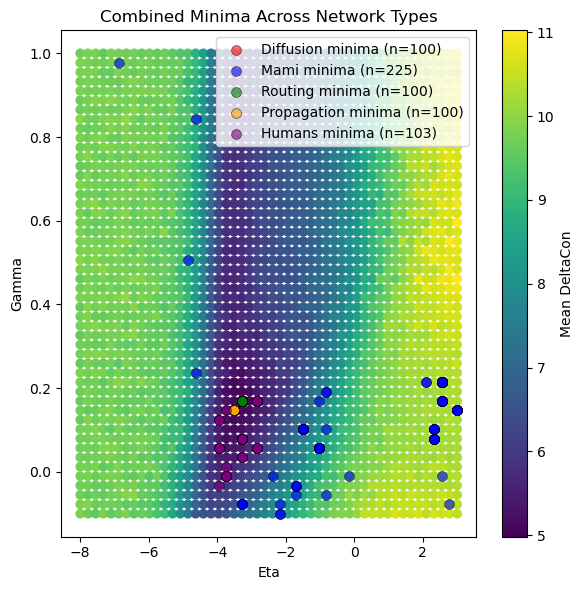


SUMMARY STATISTICS

DIFFUSION:
  Eta range: [-3.286, -3.286]
  Gamma range: [0.169, 0.169]
  Eta mean ± std: -3.286 ± 0.000
  Gamma mean ± std: 0.169 ± 0.000

MAMI:
  Eta range: [-6.878, 3.000]
  Gamma range: [-0.100, 0.978]
  Eta mean ± std: 1.135 ± 2.095
  Gamma mean ± std: 0.147 ± 0.113

ROUTING:
  Eta range: [-3.286, -3.286]
  Gamma range: [0.169, 0.169]
  Eta mean ± std: -3.286 ± 0.000
  Gamma mean ± std: 0.169 ± 0.000

PROPAGATION:
  Eta range: [-3.510, -3.510]
  Gamma range: [0.147, 0.147]
  Eta mean ± std: -3.510 ± 0.000
  Gamma mean ± std: 0.147 ± 0.000

HUMANS:
  Eta range: [-3.959, -2.837]
  Gamma range: [-0.033, 0.169]
  Eta mean ± std: -3.321 ± 0.351
  Gamma mean ± std: 0.078 ± 0.054


In [3]:

# Create the combined plot
plt.figure(figsize=(6,6), dpi=100)

# Define colors for each network type
colors = {
    'diffusion': 'red',
    'mami': 'blue',
    'routing': 'green', 
    'propagation': 'orange',
    'humans': 'purple'
}

# Plot the landscape from one network (they should be similar)
# Using diffusion as the base
base_network = 'diffusion'
df_mean = all_minima[base_network]['df_mean']
if 'DeltaCon_mean' not in df_mean.columns:
    # Calculate mean across all subjects
    delta_con_columns = [col for col in df_mean.columns if "DeltaCon_subject_" in col]
    df_mean['DeltaCon_mean'] = df_mean[delta_con_columns].mean(axis=1)

plt.scatter(df_mean["eta"], df_mean["gamma"], c=df_mean["DeltaCon_mean"], 
            cmap='viridis') # , # alpha=0.3, s=30, label='Landscape (mean DeltaCon)')

# Add colorbar for the landscape
plt.colorbar(label='Mean DeltaCon')

# Plot minima for each network type
for network_name, color in colors.items():
    minima = all_minima[network_name]
    plt.scatter(minima['eta'], minima['gamma'], 
                c=color, marker='o', s=50, alpha=0.6, 
                label=f'{network_name.capitalize()} minima (n={len(minima["eta"])})',
                edgecolors='black', linewidths=0.5)

plt.xlabel('Eta')
plt.ylabel('Gamma') 
plt.title('Combined Minima Across Network Types') 
plt.legend(loc='best')
plt.tight_layout()

# Save the figure
output_path = "/home/claude/combined_minima_plot.png"
# plt.savefig(output_path, dpi=150, bbox_inches='tight')
# print(f"\nPlot saved to: {output_path}")
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
for network_name in colors.keys():
    minima = all_minima[network_name]
    print(f"\n{network_name.upper()}:")
    print(f"  Eta range: [{np.min(minima['eta']):.3f}, {np.max(minima['eta']):.3f}]")
    print(f"  Gamma range: [{np.min(minima['gamma']):.3f}, {np.max(minima['gamma']):.3f}]")
    print(f"  Eta mean ± std: {np.mean(minima['eta']):.3f} ± {np.std(minima['eta']):.3f}")
    print(f"  Gamma mean ± std: {np.mean(minima['gamma']):.3f} ± {np.std(minima['gamma']):.3f}")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_69928/612323017.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,


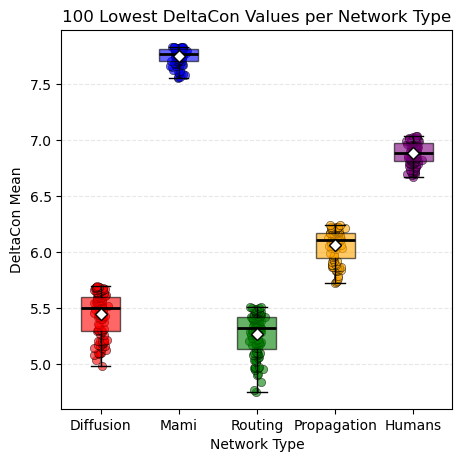


SUMMARY STATISTICS (100 LOWEST VALUES)

DIFFUSION:
  Min: 4.981106
  Q1 (25th percentile): 5.289172
  Median: 5.499660
  Q3 (75th percentile): 5.600928
  Max: 5.696073
  Mean ± std: 5.441207 ± 0.193730

MAMI:
  Min: 7.559736
  Q1 (25th percentile): 7.708207
  Median: 7.768703
  Q3 (75th percentile): 7.810609
  Max: 7.831691
  Mean ± std: 7.750956 ± 0.071672

ROUTING:
  Min: 4.752693
  Q1 (25th percentile): 5.130257
  Median: 5.318127
  Q3 (75th percentile): 5.418491
  Max: 5.509441
  Mean ± std: 5.264733 ± 0.187909

PROPAGATION:
  Min: 5.723391
  Q1 (25th percentile): 5.949541
  Median: 6.107846
  Q3 (75th percentile): 6.172643
  Max: 6.241542
  Mean ± std: 6.063378 ± 0.139625

HUMANS:
  Min: 6.667823
  Q1 (25th percentile): 6.812579
  Median: 6.885225
  Q3 (75th percentile): 6.970563
  Max: 7.041075
  Mean ± std: 6.883916 ± 0.096634


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Collect the 100 lowest DeltaCon values for each network type
boxplot_data = []
labels = []

colors_list = ['red', 'blue', 'green', 'orange', 'purple']
network_types = ['diffusion', 'mami', 'routing', 'propagation', 'humans']

for network_name in network_types:
    df_mean = all_minima[network_name]['df_mean']
    
    # Ensure DeltaCon_mean exists
    if 'DeltaCon_mean' not in df_mean.columns:
        delta_con_columns = [col for col in df_mean.columns if "DeltaCon_subject_" in col]
        df_mean['DeltaCon_mean'] = df_mean[delta_con_columns].mean(axis=1)
    
    # Get the 100 lowest values from the ENTIRE dataframe
    lowest_100 = df_mean['DeltaCon_mean'].nsmallest(100).values
    boxplot_data.append(lowest_100)
    labels.append(network_name.capitalize())

# Create the boxplot
fig, ax = plt.subplots(figsize=viz.cm_to_inch((12,12)), dpi=100)

bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,
                showmeans=True, meanline=False,
                medianprops=dict(color='black', linewidth=2),
                meanprops=dict(marker='D', markerfacecolor='white', 
                              markeredgecolor='black', markersize=6))

# Add scatter points for the 100 lowest values
for i, data in enumerate(boxplot_data):
    x = np.random.normal(i + 1, 0.04, size=len(data))  # Jitter the x-values
    ax.scatter(x, data, color=colors_list[i], alpha=0.6, edgecolor='black', linewidth=0.5)

# Color the boxes
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('DeltaCon Mean')
ax.set_xlabel('Network Type')
ax.set_title('100 Lowest DeltaCon Values per Network Type')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print summary statistics for the 100 lowest values
print("\n" + "="*60)
print("SUMMARY STATISTICS (100 LOWEST VALUES)")
print("="*60)
for i, network_name in enumerate(network_types):
    data = boxplot_data[i]
    print(f"\n{network_name.upper()}:")
    print(f"  Min: {np.min(data):.6f}")
    print(f"  Q1 (25th percentile): {np.percentile(data, 25):.6f}")
    print(f"  Median: {np.median(data):.6f}")
    print(f"  Q3 (75th percentile): {np.percentile(data, 75):.6f}")
    print(f"  Max: {np.max(data):.6f}")
    print(f"  Mean ± std: {np.mean(data):.6f} ± {np.std(data):.6f}")

In [5]:

dataset_experiment_datafile_name = {
    "hcp_schaefer_100_dataset": ["05_mst_animal_0_compared_with_hcp_schaefer_100", "00_connectomes_density10.npy"],
    "suarez_MaMI_dataset": ["05_mst_animal_0_compared_with_mami", "00_connectomes_50.npy"],
    "kaysons_generated_networks_diffusion": ["05_mst_animal_0_compared_with_diffusion", "diffusion_10_percent.npy"],
    "kaysons_generated_networks_propagation": ["05_mst_animal_0_compared_with_propagation", "propagation_10_percent.npy"],
    "kaysons_generated_networks_routing": ["05_mst_animal_0_compared_with_routing", "routing_10_percent.npy"]
}

experiment_name = "05_mst_animal_0_compared_with_routing" 
base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm")

huge_df = pd.DataFrame()
    
# combine all the metrics into one dataframe for this experiment
for dataset in dataset_experiment_datafile_name:
    experiment_name, csv_file = dataset_experiment_datafile_name[dataset]
    csv_path = base_path / f"{dataset}/{experiment_name}/metrics_2_all.csv"
    df = pd.read_csv(csv_path)
    # Add a column to identify the dataset
    df["dataset"] = dataset
    print(dataset, df.keys())
    huge_df = pd.concat([huge_df, df], ignore_index=True)


hcp_schaefer_100_dataset Index(['network_idx', 'n_connected_components', 'density', 'avg_clustering',
       'avg_degree', 'degree_assortativity', 'modularity', 'transitivity',
       'topological_distance_mean', 'topological_distance_std', 'degree_gini',
       'structural_complexity', 'directed_simplices_count',
       'directed_simplices_max_size', 'spectral_radius', 'spectral_gap',
       'global_efficiency', 'diffusion_efficiency', 'propagation_efficiency',
       'nct_control_avg', 'nct_control_std', 'nct_control_max',
       'nct_control_n_nodes_90_percent', 'nct_control_n_nodes_50_percent',
       'nct_control_n_nodes_10_percent', 'nct_energies_total',
       'nct_energies_std', 'nct_energies_max',
       'nct_energies_n_nodes_90_percent', 'nct_energies_n_nodes_50_percent',
       'nct_energies_n_nodes_10_percent',
       'synchronizability_eigenratio_eigenratio',
       'synchronizability_eigenratio_lambda_2',
       'synchronizability_eigenratio_lambda_N',
       'kernel_rank

In [6]:
huge_df

,network_idx,n_connected_components,density,avg_clustering,avg_degree,degree_assortativity,modularity,transitivity,topological_distance_mean,topological_distance_std,...,nct_energies_n_nodes_10_percent,synchronizability_eigenratio_eigenratio,synchronizability_eigenratio_lambda_2,synchronizability_eigenratio_lambda_N,kernel_rank_thresholded_and_summed_0.01,kernel_rank_max,kernel_rank_phase_of_lambda_max,kernel_rank_phase_diff_of_lambda_max_and_2nd,effective_dimensionality,dataset
0,0.0,1.0,0.1,0.463335,9.9,0.024741,0.503820,0.376459,0.890220,0.172178,...,2.0,30.535816,0.805902,24.608872,95.0,11.669819,0.0,0.0,57.068725,hcp_schaefer_100_dataset
1,1.0,1.0,0.1,0.441039,9.9,0.110950,0.514470,0.379672,0.892455,0.171647,...,2.0,25.245418,0.863788,21.806685,97.0,11.723267,0.0,0.0,56.582547,hcp_schaefer_100_dataset
2,2.0,1.0,0.1,0.454073,9.9,0.072914,0.492193,0.389313,0.893217,0.171215,...,2.0,26.986302,0.905820,24.444738,97.0,11.434837,0.0,0.0,57.583679,hcp_schaefer_100_dataset
3,3.0,1.0,0.1,0.425323,9.9,0.131410,0.495458,0.382317,0.894314,0.169087,...,2.0,26.075633,0.788819,20.568966,97.0,11.594978,0.0,0.0,58.659774,hcp_schaefer_100_dataset
4,4.0,1.0,0.1,0.485091,9.9,-0.015772,0.524083,0.404494,0.892184,0.175680,...,2.0,27.569574,0.760979,20.979866,98.0,11.249977,0.0,0.0,56.899911,hcp_schaefer_100_dataset
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,95.0,1.0,0.1,0.530755,9.9,0.454171,0.566195,0.527068,0.897523,0.193109,...,2.0,34.024986,0.602045,20.484578,95.0,12.547681,0.0,0.0,52.945825,kaysons_generated_networks_routing
621,96.0,1.0,0.1,0.530755,9.9,0.454171,0.582947,0.527068,0.897523,0.193109,...,2.0,34.024986,0.602045,20.484578,95.0,12.547681,0.0,0.0,52.945825,kaysons_generated_networks_routing
622,97.0,1.0,0.1,0.530755,9.9,0.454171,0.575902,0.527068,0.897523,0.193109,...,2.0,34.024986,0.602045,20.484578,95.0,12.547681,0.0,0.0,52.945825,kaysons_generated_networks_routing
623,98.0,1.0,0.1,0.530755,9.9,0.454171,0.577364,0.527068,0.897523,0.193109,...,2.0,34.024986,0.602045,20.484578,95.0,12.547681,0.0,0.0,52.945825,kaysons_generated_networks_routing


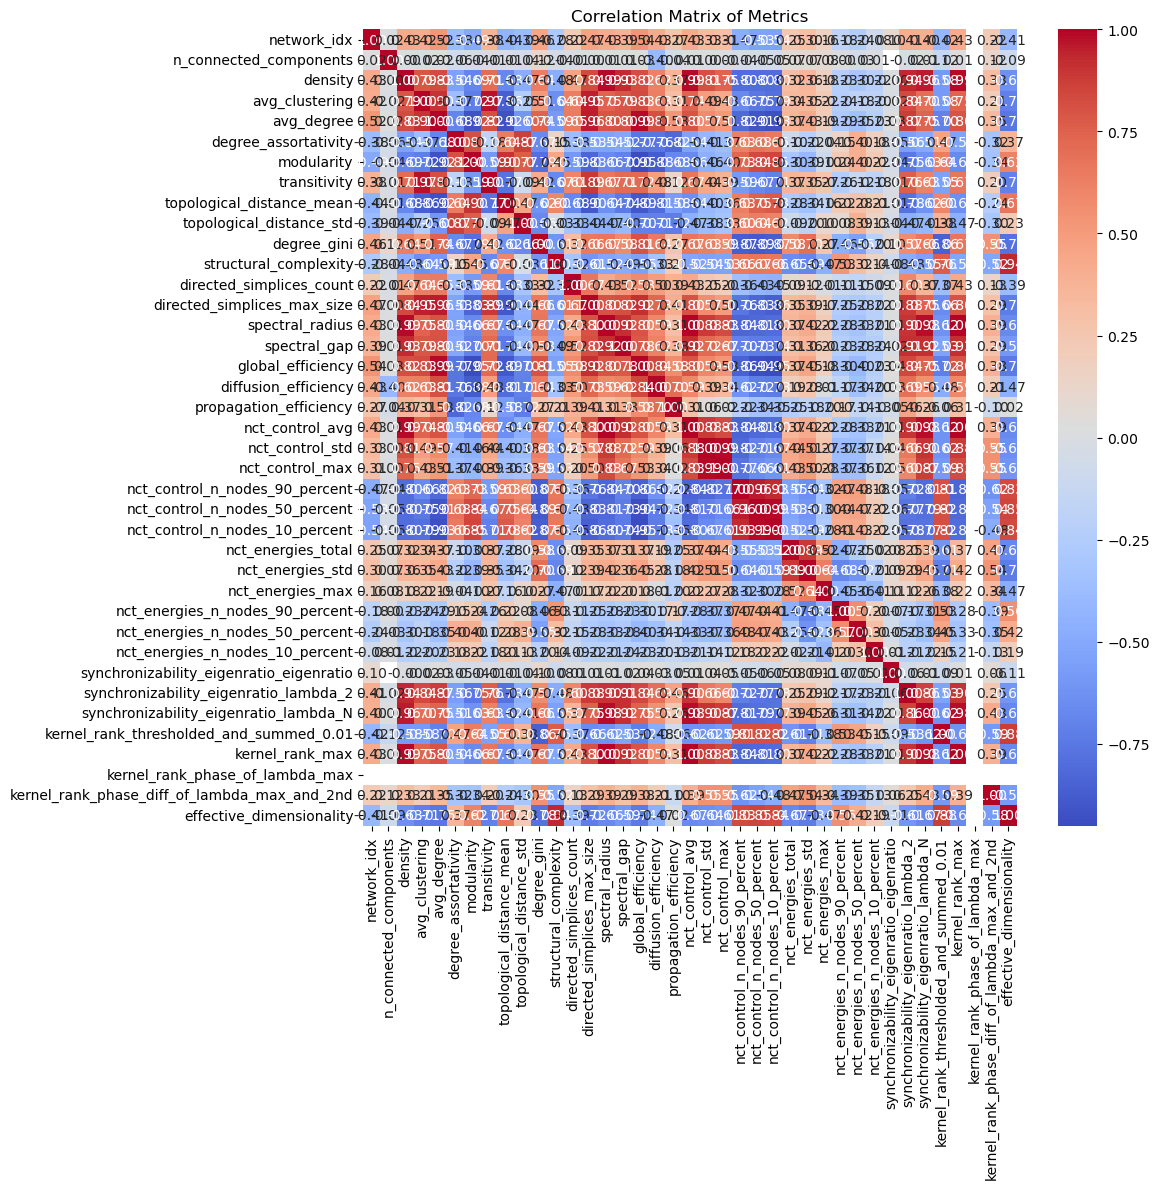

In [7]:
# Make a correlation axis between the columns of the huge_df. Don't use the dataset column for this, only the metric columns.
correlation_matrix = huge_df.drop(columns=["dataset"]).corr()
plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Metrics")
plt.tight_layout()
plt.show()

Index(['n_connected_components', 'density', 'avg_clustering', 'avg_degree',
       'degree_assortativity', 'modularity', 'transitivity',
       'topological_distance_mean', 'topological_distance_std', 'degree_gini',
       'structural_complexity', 'directed_simplices_count',
       'directed_simplices_max_size', 'spectral_radius', 'spectral_gap',
       'global_efficiency', 'diffusion_efficiency', 'propagation_efficiency',
       'nct_control_avg', 'nct_control_std', 'nct_control_max',
       'nct_control_n_nodes_90_percent', 'nct_control_n_nodes_50_percent',
       'nct_control_n_nodes_10_percent', 'nct_energies_total',
       'nct_energies_std', 'nct_energies_max',
       'nct_energies_n_nodes_90_percent', 'nct_energies_n_nodes_50_percent',
       'nct_energies_n_nodes_10_percent',
       'synchronizability_eigenratio_eigenratio',
       'synchronizability_eigenratio_lambda_2',
       'synchronizability_eigenratio_lambda_N',
       'kernel_rank_thresholded_and_summed_0.01', 'kernel_r

/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul

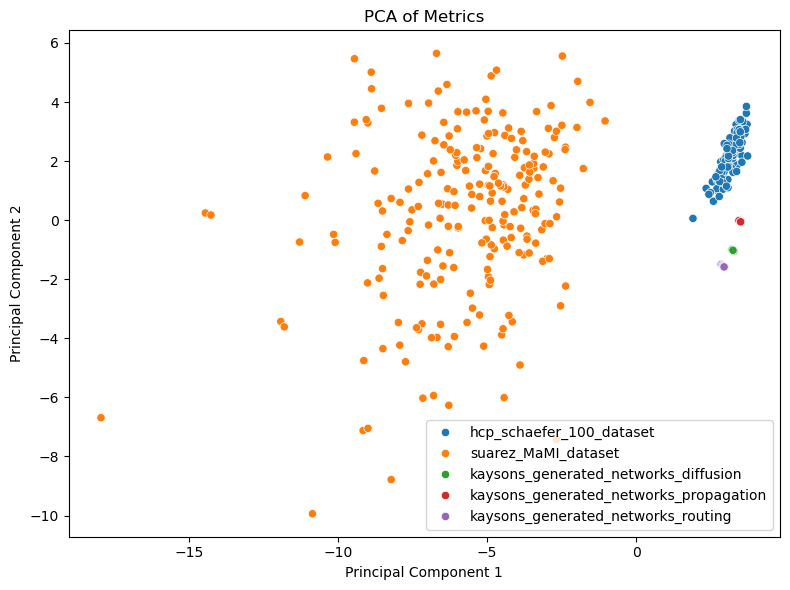

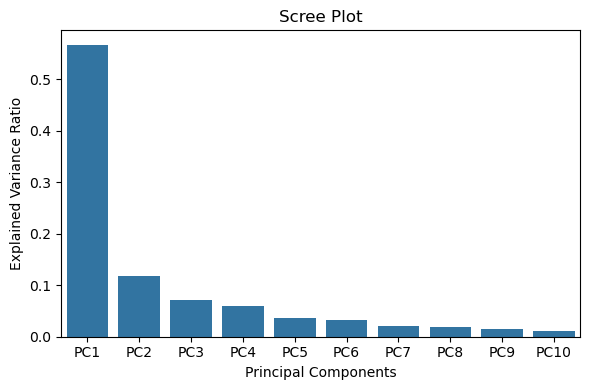

In [11]:
# Create a PCA between the columns of the huge_df
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# For pca always drop the dataset column and only use the metric columns
huge_df_metrics = huge_df.drop(columns=["dataset", "network_idx"])
print(huge_df_metrics.keys())

# print all max values of all columns in huge_df_metrics
print("\nMax values of metrics:")
for col in huge_df_metrics.columns:
    print(f"{col}: {huge_df_metrics[col].max():.4f}")
print("\nMin values of metrics:")
for col in huge_df_metrics.columns:
    print(f"{col}: {huge_df_metrics[col].min():.4f}")
    
# Drop the columns that have inf or -inf values (if any). Print the dropped columns
dropped_cols = huge_df_metrics.columns[huge_df_metrics.isnull().any()].tolist()
huge_df_metrics.replace([np.inf, -np.inf], np.nan, inplace=True)
huge_df_metrics.dropna(axis=1, inplace=True)
print(f"Dropped columns: {dropped_cols}")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(huge_df_metrics)

pca = PCA(n_components=10)
pca_result = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=huge_df['dataset'])
plt.title("PCA of Metrics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

# Scree plot to show explained variance
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance)
plt.title("Scree Plot")
plt.ylabel("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.tight_layout()
plt.show()

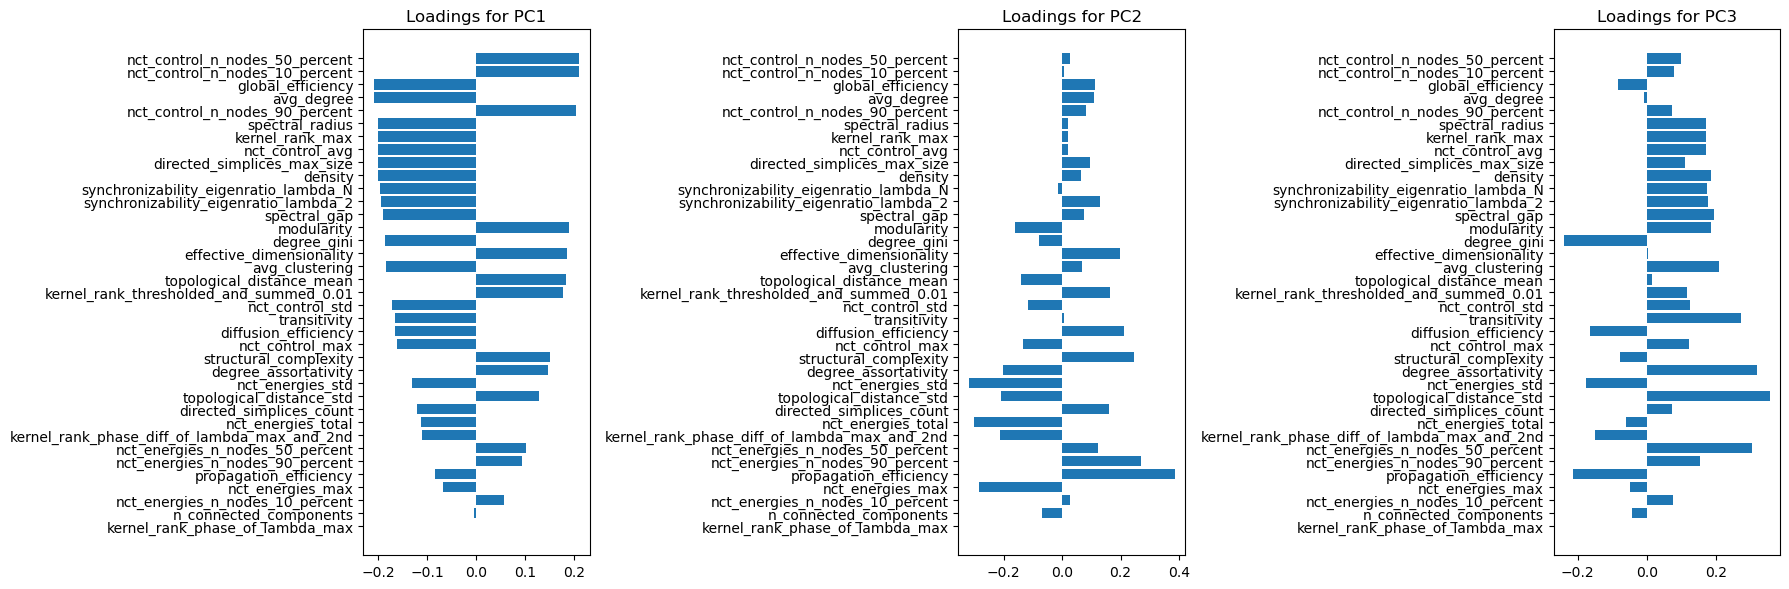

In [13]:
# Subplots of loadings for the first 3 principal components
loadings = pca.components_.T
num_metrics = loadings.shape[0]
metric_names = huge_df_metrics.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort(np.abs(loadings[:, 0])) #[::-1]
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(3):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")
plt.tight_layout()
plt.show()



In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

class MetricSelector:
    """Interactive tool for selecting metrics while avoiding high correlations."""
    
    def __init__(self, correlation_matrix, threshold=0.95):
        """
        Initialize the metric selector.
        
        Parameters:
        -----------
        correlation_matrix : pd.DataFrame
            Correlation matrix of all metrics
        threshold : float
            Correlation threshold above which metrics are considered too similar
        """
        self.corr_matrix = correlation_matrix
        self.threshold = threshold
        self.selected_metrics = []
        self.excluded_metrics = []
        
    def find_high_correlations(self):
        """Find all pairs of metrics with correlation above threshold."""
        high_corr_pairs = []
        
        # Get upper triangle of correlation matrix (avoid duplicates)
        for i in range(len(self.corr_matrix.columns)):
            for j in range(i+1, len(self.corr_matrix.columns)):
                metric1 = self.corr_matrix.columns[i]
                metric2 = self.corr_matrix.columns[j]
                corr_value = abs(self.corr_matrix.iloc[i, j])
                
                if corr_value > self.threshold:
                    high_corr_pairs.append({
                        'metric1': metric1,
                        'metric2': metric2,
                        'correlation': corr_value
                    })
        
        return pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)
    
    def get_conflict_groups(self):
        """Group metrics that are highly correlated with each other."""
        high_corr_df = self.find_high_correlations()
        
        if len(high_corr_df) == 0:
            return []
        
        # Build groups of correlated metrics
        groups = []
        processed = set()
        
        for _, row in high_corr_df.iterrows():
            m1, m2 = row['metric1'], row['metric2']
            
            # Find if either metric is already in a group
            found_group = None
            for group in groups:
                if m1 in group or m2 in group:
                    found_group = group
                    break
            
            if found_group:
                found_group.add(m1)
                found_group.add(m2)
            else:
                groups.append({m1, m2})
        
        return [sorted(list(g)) for g in groups]
    
    def analyze_metric_conflicts(self, metric):
        """Show which metrics conflict with a given metric."""
        conflicts = []
        
        for other_metric in self.corr_matrix.columns:
            if metric != other_metric:
                corr_value = abs(self.corr_matrix.loc[metric, other_metric])
                if corr_value > self.threshold:
                    conflicts.append({
                        'conflicting_metric': other_metric,
                        'correlation': corr_value
                    })
        
        return pd.DataFrame(conflicts).sort_values('correlation', ascending=False) if conflicts else pd.DataFrame()
    
    def suggest_selection_order(self):
        """Suggest an order to review metrics based on number of conflicts."""
        conflict_counts = {}
        
        for metric in self.corr_matrix.columns:
            conflicts = self.analyze_metric_conflicts(metric)
            conflict_counts[metric] = len(conflicts)
        
        # Sort by number of conflicts (descending) - tackle problematic metrics first
        sorted_metrics = sorted(conflict_counts.items(), key=lambda x: x[1], reverse=True)
        
        return pd.DataFrame(sorted_metrics, columns=['metric', 'num_conflicts'])
    
    def visualize_conflict_network(self, figsize=(15, 10)):
        """Visualize metrics and their correlations as a network."""
        import networkx as nx
        
        high_corr_df = self.find_high_correlations()
        
        if len(high_corr_df) == 0:
            print("No high correlations found above threshold!")
            return
        
        G = nx.Graph()
        
        # Add edges for high correlations
        for _, row in high_corr_df.iterrows():
            G.add_edge(row['metric1'], row['metric2'], weight=row['correlation'])
        
        plt.figure(figsize=figsize)
        pos = nx.spring_layout(G, k=2, iterations=50)
        
        # Draw nodes
        nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='lightblue', alpha=0.7)
        
        # Draw edges with width based on correlation
        edges = G.edges()
        weights = [G[u][v]['weight'] for u, v in edges]
        nx.draw_networkx_edges(G, pos, width=[w*3 for w in weights], alpha=0.5)
        
        # Draw labels
        nx.draw_networkx_labels(G, pos, font_size=10)
        
        plt.title(f"Network of Highly Correlated Metrics (|r| > {self.threshold})", fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        return G
    
    def create_decision_summary(self):
        """Create a summary table to help with manual selection."""
        groups = self.get_conflict_groups()
        
        if not groups:
            print(f"✓ No metrics correlate above {self.threshold}! All metrics can be included.")
            return None
        
        print(f"\n{'='*80}")
        print(f"CONFLICT GROUPS (correlation > {self.threshold})")
        print(f"{'='*80}\n")
        
        summaries = []
        
        for i, group in enumerate(groups, 1):
            print(f"\nGroup {i}: {len(group)} conflicting metrics")
            print("-" * 80)
            
            for metric in group:
                conflicts = self.analyze_metric_conflicts(metric)
                # Only show conflicts within this group
                group_conflicts = conflicts[conflicts['conflicting_metric'].isin(group)]
                
                summaries.append({
                    'group': i,
                    'metric': metric,
                    'conflicts_in_group': len(group_conflicts),
                    'avg_correlation': group_conflicts['correlation'].mean() if len(group_conflicts) > 0 else 0
                })
                
                print(f"  {metric}")
                if len(group_conflicts) > 0:
                    for _, conflict in group_conflicts.iterrows():
                        print(f"    ├─ {conflict['conflicting_metric']}: r={conflict['correlation']:.3f}")
            
            print(f"\n  → DECISION: Select 1 metric from this group")
        
        return pd.DataFrame(summaries)
    
    def interactive_selection(self):
        """Guide through interactive selection process."""
        print("\n" + "="*80)
        print("INTERACTIVE METRIC SELECTION")
        print("="*80)
        
        # Show summary
        summary_df = self.create_decision_summary()
        
        if summary_df is None:
            return list(self.corr_matrix.columns)
        
        groups = self.get_conflict_groups()
        selected = []
        
        print("\n\nFor each group, select the most interpretable metric:\n")
        
        for i, group in enumerate(groups, 1):
            print(f"\nGroup {i}: Choose 1 from {group}")
            print("-" * 40)
            
            # This would be interactive in a Jupyter notebook
            # For now, just return the groups for manual selection
            
        return groups


# Main analysis function
def analyze_and_select_metrics(correlation_matrix, threshold=0.95):
    """
    Main function to analyze correlations and guide metric selection.
    
    Parameters:
    -----------
    correlation_matrix : pd.DataFrame
        Correlation matrix of metrics
    threshold : float
        Correlation threshold (default 0.95)
    
    Returns:
    --------
    MetricSelector object with analysis results
    """
    selector = MetricSelector(correlation_matrix, threshold)
    
    # 1. Show high correlations
    print("="*80)
    print("HIGH CORRELATIONS FOUND")
    print("="*80)
    high_corr = selector.find_high_correlations()
    if len(high_corr) > 0:
        print(f"\nFound {len(high_corr)} pairs with |correlation| > {threshold}:\n")
        print(high_corr.to_string(index=False))
    else:
        print(f"\nNo correlations above {threshold} found!")
    
    # 2. Show conflict groups
    print("\n")
    summary = selector.create_decision_summary()
    
    # 3. Show suggestion order
    print("\n" + "="*80)
    print("SUGGESTED REVIEW ORDER (by number of conflicts)")
    print("="*80)
    order = selector.suggest_selection_order()
    print(order.to_string(index=False))
    
    # 4. Visualize network
    print("\n\nGenerating conflict network visualization...")
    selector.visualize_conflict_network()
    
    return selector


# Example usage:
if __name__ == "__main__":
    # This is an example - replace with your actual correlation matrix
    print("Import this module and use:")
    print("  selector = analyze_and_select_metrics(correlation_matrix, threshold=0.95)")
    print("  groups = selector.get_conflict_groups()")

Import this module and use:
  selector = analyze_and_select_metrics(correlation_matrix, threshold=0.95)
  groups = selector.get_conflict_groups()


hcp_schaefer_100_dataset Index(['network_idx', 'n_connected_components', 'density', 'avg_clustering',
       'avg_degree', 'degree_assortativity', 'modularity', 'transitivity',
       'topological_distance_mean', 'topological_distance_std', 'degree_gini',
       'structural_complexity', 'directed_simplices_count',
       'directed_simplices_max_size', 'spectral_radius', 'spectral_gap',
       'global_efficiency', 'diffusion_efficiency', 'propagation_efficiency',
       'nct_control_avg', 'nct_control_std', 'nct_control_max',
       'nct_control_n_nodes_90_percent', 'nct_control_n_nodes_50_percent',
       'nct_control_n_nodes_10_percent', 'nct_energies_total',
       'nct_energies_std', 'nct_energies_max',
       'nct_energies_n_nodes_90_percent', 'nct_energies_n_nodes_50_percent',
       'nct_energies_n_nodes_10_percent',
       'synchronizability_eigenratio_eigenratio',
       'synchronizability_eigenratio_lambda_2',
       'synchronizability_eigenratio_lambda_N',
       'kernel_rank

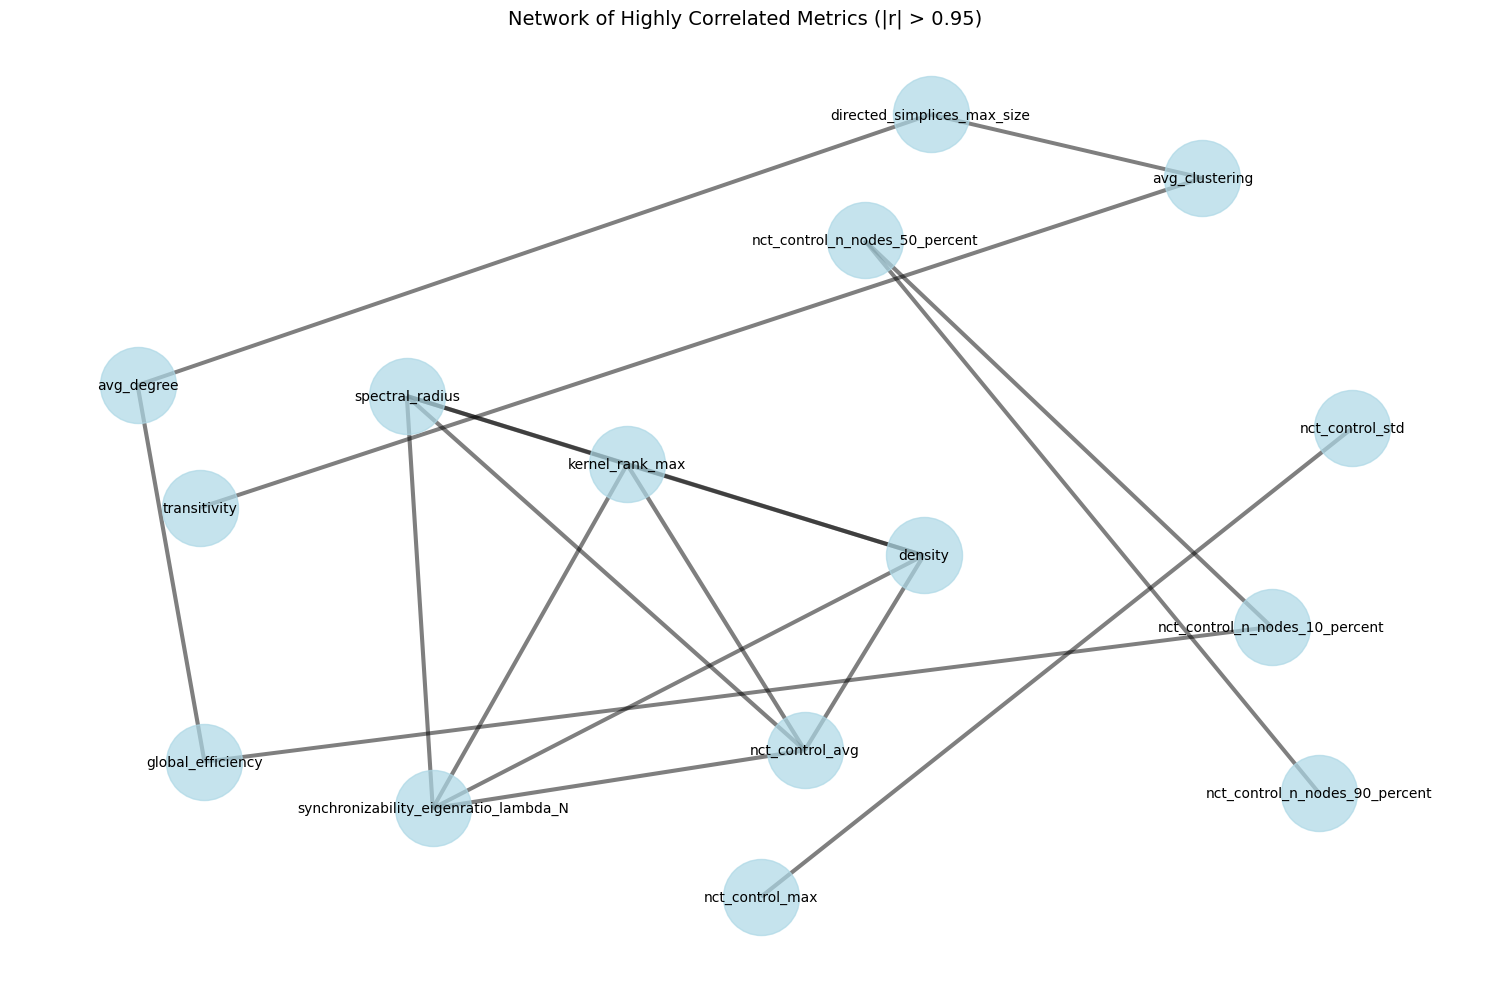



STEP 2: MAKE YOUR SELECTIONS

Based on the groups above, fill in your selections:

manual_selections = {
    1: 'metric_name_you_choose',  # From: ['density', 'kernel_rank_max', 'nct_control_avg', 'spectral_radius', 'synchronizability_eigenratio_lambda_N']
    2: 'metric_name_you_choose',  # From: ['global_efficiency', 'nct_control_n_nodes_10_percent', 'nct_control_n_nodes_50_percent', 'nct_control_n_nodes_90_percent']
    3: 'metric_name_you_choose',  # From: ['avg_clustering', 'avg_degree', 'directed_simplices_max_size', 'global_efficiency']
    4: 'metric_name_you_choose',  # From: ['nct_control_max', 'nct_control_std']
    5: 'metric_name_you_choose',  # From: ['avg_clustering', 'transitivity']
}



NEXT STEPS:

1. Review the conflict groups and network visualization above
2. For each group, choose the most interpretable metric
3. Fill in the manual_selections dictionary
4. Run the validation:

   # After filling in manual_selections:
   final_metrics = create_final_metric_list(c

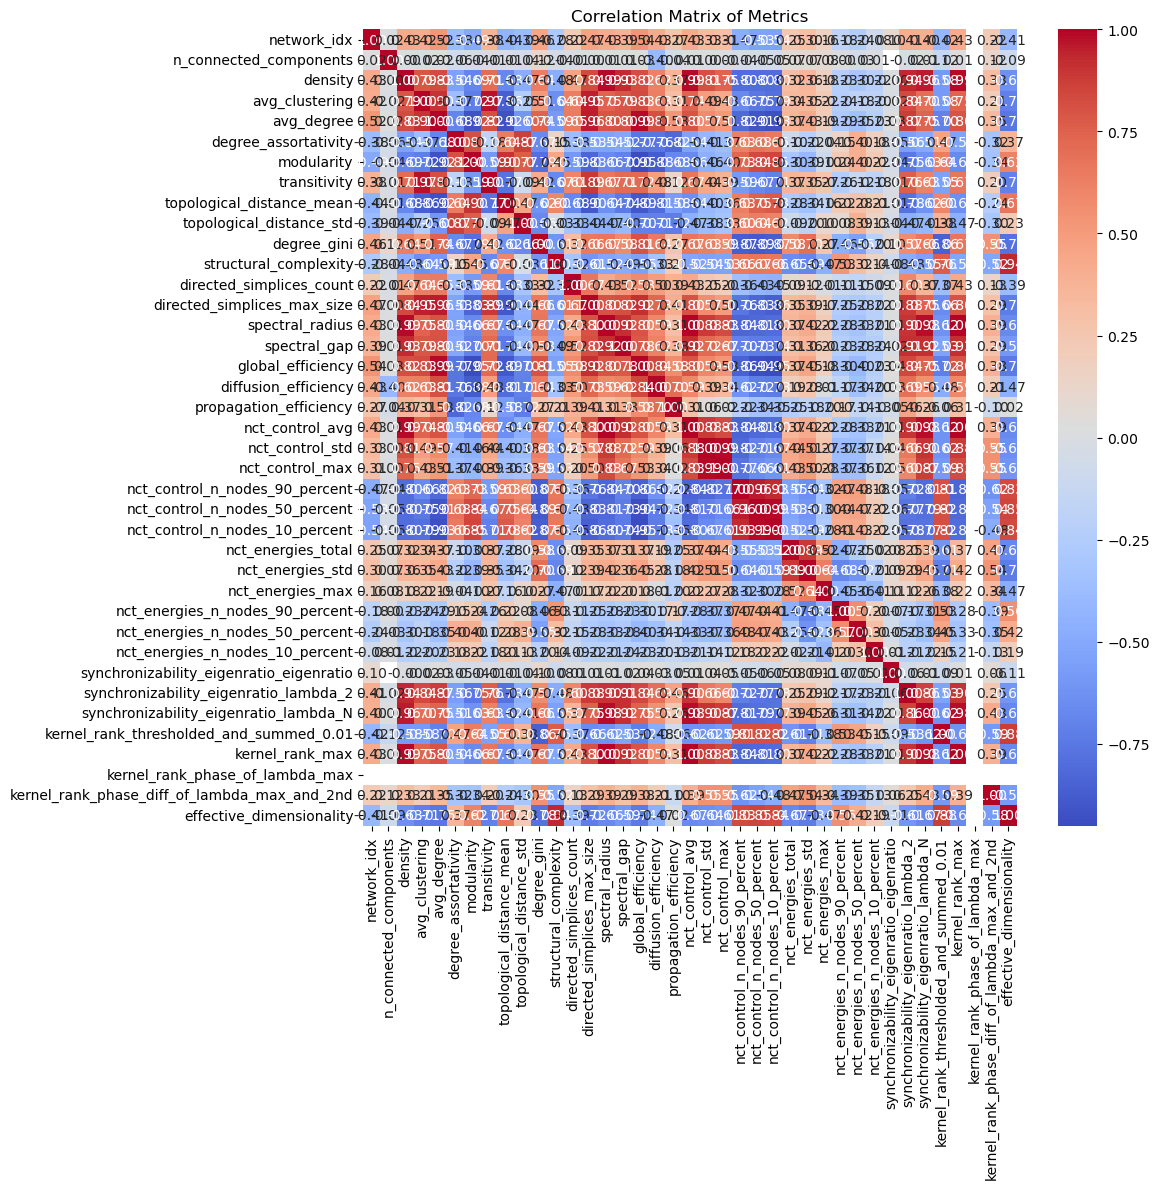

In [15]:
"""
Usage script for metric selection with your correlation matrix.

This script will:
1. Identify all groups of metrics that correlate > 0.95
2. Present them in an organized way for you to make decisions
3. Generate visualizations to help you understand the relationships
4. Create a final selected metric list for PCA
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# from metric_selector import MetricSelector, analyze_and_select_metrics

# === YOUR EXISTING CODE ===
dataset_experiment_datafile_name = {
    "hcp_schaefer_100_dataset": ["05_mst_animal_0_compared_with_hcp_schaefer_100", "00_connectomes_density10.npy"],
    "suarez_MaMI_dataset": ["05_mst_animal_0_compared_with_mami", "00_connectomes_50.npy"],
    "kaysons_generated_networks_diffusion": ["05_mst_animal_0_compared_with_diffusion", "diffusion_10_percent.npy"],
    "kaysons_generated_networks_propagation": ["05_mst_animal_0_compared_with_propagation", "propagation_10_percent.npy"],
    "kaysons_generated_networks_routing": ["05_mst_animal_0_compared_with_routing", "routing_10_percent.npy"]
}

experiment_name = "05_mst_animal_0_compared_with_routing" 
base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm")

huge_df = pd.DataFrame()
    
# Combine all the metrics into one dataframe for this experiment
for dataset in dataset_experiment_datafile_name:
    experiment_name, csv_file = dataset_experiment_datafile_name[dataset]
    csv_path = base_path / f"{dataset}/{experiment_name}/metrics_2_all.csv"
    df = pd.read_csv(csv_path)
    df["dataset"] = dataset
    print(dataset, df.keys())
    huge_df = pd.concat([huge_df, df], ignore_index=True)

# Calculate correlation matrix
correlation_matrix = huge_df.drop(columns=["dataset"]).corr()

# === METRIC SELECTION WORKFLOW ===

print("\n" + "="*80)
print("STEP 1: ANALYZE CORRELATIONS")
print("="*80)

# Run the analysis
selector = analyze_and_select_metrics(correlation_matrix, threshold=0.95)

# === STEP 2: MANUAL SELECTION ===

print("\n\n" + "="*80)
print("STEP 2: MAKE YOUR SELECTIONS")
print("="*80)

# Get conflict groups
groups = selector.get_conflict_groups()

# Create a manual selection dictionary
# YOU FILL THIS IN based on interpretability
manual_selections = {}

print("\nBased on the groups above, fill in your selections:")
print("\nmanual_selections = {")
for i, group in enumerate(groups, 1):
    print(f"    {i}: 'metric_name_you_choose',  # From: {group}")
print("}\n")

# === EXAMPLE: Manual selections (you replace this) ===
# Uncomment and modify based on your actual groups:
# manual_selections = {
#     1: 'metric_A',  # Most interpretable from group 1
#     2: 'metric_X',  # Most interpretable from group 2
#     # ... etc
# }

# === STEP 3: CREATE FINAL METRIC LIST ===

def create_final_metric_list(correlation_matrix, groups, manual_selections):
    """
    Create final list of metrics for PCA.
    
    Parameters:
    -----------
    correlation_matrix : pd.DataFrame
        Full correlation matrix
    groups : list of lists
        Conflict groups from selector
    manual_selections : dict
        Manual selections for each group {group_num: metric_name}
    
    Returns:
    --------
    list of selected metric names
    """
    all_metrics = set(correlation_matrix.columns)
    conflicting_metrics = set()
    
    # Collect all metrics in conflict groups
    for group in groups:
        conflicting_metrics.update(group)
    
    # Start with non-conflicting metrics
    selected_metrics = list(all_metrics - conflicting_metrics)
    
    # Add manual selections from each group
    for group_num, metric in manual_selections.items():
        if metric in conflicting_metrics:
            selected_metrics.append(metric)
    
    return sorted(selected_metrics)


# === STEP 4: VALIDATION ===

def validate_selections(correlation_matrix, selected_metrics, threshold=0.95):
    """Verify that selected metrics don't correlate > threshold."""
    selected_corr = correlation_matrix.loc[selected_metrics, selected_metrics]
    
    # Check for high correlations
    high_corrs = []
    for i in range(len(selected_metrics)):
        for j in range(i+1, len(selected_metrics)):
            corr_val = abs(selected_corr.iloc[i, j])
            if corr_val > threshold:
                high_corrs.append({
                    'metric1': selected_metrics[i],
                    'metric2': selected_metrics[j],
                    'correlation': corr_val
                })
    
    if len(high_corrs) == 0:
        print(f"\n✓ SUCCESS! All selected metrics have |correlation| ≤ {threshold}")
        print(f"  Total metrics selected: {len(selected_metrics)}")
    else:
        print(f"\n✗ WARNING! Found {len(high_corrs)} pairs with |correlation| > {threshold}:")
        for pair in high_corrs:
            print(f"  {pair['metric1']} <-> {pair['metric2']}: r={pair['correlation']:.3f}")
    
    return len(high_corrs) == 0


# === HELPER: Save selection results ===

def save_selection_results(selected_metrics, output_path="selected_metrics.txt"):
    """Save the final metric list to a file."""
    with open(output_path, 'w') as f:
        f.write("Selected Metrics for PCA\n")
        f.write("="*50 + "\n\n")
        for i, metric in enumerate(selected_metrics, 1):
            f.write(f"{i}. {metric}\n")
    
    print(f"\nSaved selected metrics to: {output_path}")


# === USAGE EXAMPLE ===

print("\n\n" + "="*80)
print("NEXT STEPS:")
print("="*80)
print("""
1. Review the conflict groups and network visualization above
2. For each group, choose the most interpretable metric
3. Fill in the manual_selections dictionary
4. Run the validation:

   # After filling in manual_selections:
   final_metrics = create_final_metric_list(correlation_matrix, groups, manual_selections)
   is_valid = validate_selections(correlation_matrix, final_metrics, threshold=0.95)
   
   if is_valid:
       save_selection_results(final_metrics)
       # Use final_metrics for your PCA
       pca_data = huge_df[final_metrics]
""")

# Show the correlation heatmap as before
plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Metrics")
plt.tight_layout()
plt.show()

([0, 1, 2, 3, 4],
 [Text(0, 0, 'hcp_schaefer_100_dataset'),
  Text(1, 0, 'suarez_MaMI_dataset'),
  Text(2, 0, 'kaysons_generated_networks_diffusion'),
  Text(3, 0, 'kaysons_generated_networks_propagation'),
  Text(4, 0, 'kaysons_generated_networks_routing')])

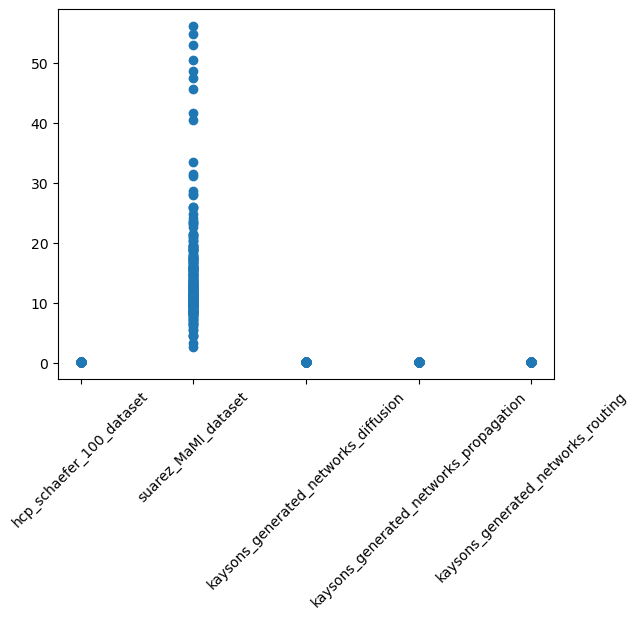

In [21]:
plt.scatter(huge_df["dataset"], huge_df["density"])
plt.xticks(rotation=45)

In [50]:
# conns = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/00_connectomes_50.npy")
conns = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/01_consensus_bin_density_10_percent_50.npy") 
# conns = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100_dataset/01_connectomes/00_connectomes_density10.npy")
# conns = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/kaysons_generated_networks_diffusion/05_mst_animal_0_compared_with_diffusion/generated_networks/net_eta-0.36734688282013_gamma-0.010204084217549_ruleMatchingIndex_id001.npy")
# conns = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_routing/01_connectomes/routing_10.npy")
# conns = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/10_mst_9_animal_0/generated_networks/net_eta-2.5_gamma-0.100000001490117_ruleMatchingIndex_id001.npy")
# conns = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/10_mst_9_animal_0/generated_networks/net_eta3.0_gamma1.0_ruleMatchingIndex_id016.npy")
# conns = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/10_mst_9_animal_0/generated_networks/net_eta3.0_gamma-0.100000001490117_ruleMatchingIndex_id017.npy")
# conns = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/10_mst_9_animal_0/generated_networks/net_eta-2.5_gamma-0.100000001490117_ruleMatchingIndex_id000.npy") 
conns.shape

(225, 100, 100)

In [51]:
for c in conns: 
    print(np.mean(c))

0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.099
0.09